<a href="https://colab.research.google.com/github/romeurf/DipRadar/blob/main/ml_training/DipRadar_Training_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 DipRadar — ML Training (Colab)

Pipeline completo de treino dos modelos ML que correm no Railway.

**Outputs gerados e pushed para GitHub:**
- `dip_models_v3.pkl` → bundle do modelo (joblib)
- `ml_report_v3.json` → métricas e metadados do treino
- `ml_training_base.parquet` → dataset de treino completo

**Fluxo (correr em ordem):**
1. Célula 1 — Secrets + clone do repo + install deps
2. Célula 2 — Download de preços via yfinance (ETFs + ~800 tickers do universo)
3. Célula 2.5 — Enriquecimento de sectores via yfinance (sem sectors.py)
4. Célula 3 — Build do dataset de treino (features + targets)
5. Célula 4 — Walk-forward CV + seleção do champion
6. Célula 5 — Treino full + calibrador isotónico
7. Célula 6 — Bundle + Report
8. Célula 7 — Guardar parquet actualizado
9. Célula 8 — Push automático para GitHub (Railway redeploy automático)

## ⚙️ Célula 1 — Setup: secrets, clone, install deps

In [1]:
import os, subprocess, sys
from google.colab import userdata

GITHUB_TOKEN = userdata.get('GITHUB_API_KEY')
REPO_OWNER   = 'romeurf'
REPO_NAME    = 'DipRadar'
BRANCH       = 'main'

assert GITHUB_TOKEN, 'Falta GITHUB_TOKEN nos secrets do Colab'
print('✅ Secrets carregados')

REPO_URL = f'https://{GITHUB_TOKEN}@github.com/{REPO_OWNER}/{REPO_NAME}.git'
REPO_DIR = f'/content/{REPO_NAME}'

if not os.path.exists(REPO_DIR):
    subprocess.run(['git', 'clone', '--depth=1', '-b', BRANCH, REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(['git', '-C', REPO_DIR, 'pull', 'origin', BRANCH], check=True)

os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)
print(f'✅ Repo em {REPO_DIR}')

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'joblib', 'scikit-learn', 'lightgbm', 'xgboost',
                'pandas', 'pyarrow', 'yfinance', 'imbalanced-learn'], check=True)
print('✅ Dependências instaladas')

✅ Secrets carregados
✅ Repo em /content/DipRadar
✅ Dependências instaladas


## 🌐 Célula 2 — Download de preços via yfinance (~800 tickers)

In [2]:
import yfinance as yf
import pandas as pd
from pathlib import Path
from ml_training.config import DEFAULT_ETF, SECTOR_ETF
from ml_training.price_fetch import load_etf_cache

REPO_PATH     = Path(REPO_DIR)
ETF_CACHE_DIR = REPO_PATH / 'ml_training' / 'etf_cache'
ETF_CACHE_DIR.mkdir(parents=True, exist_ok=True)

etf_tickers = sorted(set([DEFAULT_ETF] + list(SECTOR_ETF.values())))
print(f'ETFs a descarregar: {etf_tickers}')

etf_cache = load_etf_cache(
    etfs=etf_tickers,
    start='2018-01-01',
    cache_dir=ETF_CACHE_DIR,
)

print(f'\n✅ ETF cache: {len(etf_cache)}/{len(etf_tickers)} ETFs carregados')
if len(etf_cache) == 0:
    raise RuntimeError('Nenhum ETF carregado — verifica a ligação à Internet no Colab.')

ETFs a descarregar: ['SPY', 'XLB', 'XLC', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY']


[*********************100%***********************]  12 of 12 completed



✅ ETF cache: 12/12 ETFs carregados


In [3]:
try:
    from universe import (
        _SP500_FALLBACK, _NASDAQ100_FALLBACK, _STOXX200, _FTSE100,
        USER_PORTFOLIO, USER_WATCHLIST, ETF_TICKERS
    )
    _raw = USER_PORTFOLIO + USER_WATCHLIST + _SP500_FALLBACK + _NASDAQ100_FALLBACK + _STOXX200 + _FTSE100
    _seen = set()
    all_tickers = []
    for t in _raw:
        t = t.strip().upper()
        if t and t not in _seen and t not in ETF_TICKERS:
            _seen.add(t)
            all_tickers.append(t)
    all_tickers = sorted(all_tickers)
    print(f'✅ universe.py: {len(all_tickers)} tickers')
except Exception as e:
    print(f'⚠️  universe.py falhou ({e}) — lista mínima')
    ETF_TICKERS = set()
    all_tickers = sorted(['AAPL','MSFT','GOOGL','AMZN','META','NVDA','TSLA','BRK-B',
        'JNJ','UNH','LLY','ABBV','MRK','ABT','TMO','DHR',
        'JPM','BAC','WFC','GS','MS','BLK',
        'PG','KO','PEP','WMT','COST','MCD','HD','TGT',
        'XOM','CVX','COP','SLB','NEE','DUK','SO',
        'CAT','DE','HON','MMM','GE','RTX','VZ','T','CMCSA',
        'AMT','PLD','EQIX','LIN','APD','SHW',
        'NVO','ADBE','UBER','ADP','CRM','CRWD','PLTR','NOW',])

✅ universe.py: 704 tickers


In [4]:
from ml_training.price_fetch import fetch_ohlcv_batch
from datetime import date

START_DATE = '2018-01-01'
END_DATE   = date.today().strftime('%Y-%m-%d')

print(f'A descarregar preços de {len(all_tickers)} tickers...')
price_cache = fetch_ohlcv_batch(
    tickers_list=all_tickers,
    start=START_DATE,
    end=END_DATE,
    batch_size=40,
    progress_log=True,
)
not_found = [t for t in all_tickers if t not in price_cache]
print(f'\n✅ Price cache: {len(price_cache)}/{len(all_tickers)} tickers')
print(f'   Não encontrados: {len(not_found)}')

A descarregar preços de 704 tickers...


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ANSS"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ANSS']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['BCR']: YFPricesMissingError('possibly delisted; no price data found  (1d 2018-01-01 -> 2026-05-06)')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['CRH.I']: YFPricesMissingError('possibly delisted; no price data found  (1d 2018-01-01 -> 2026-05-06)')
ERROR:yfinance:
4 Failed downloads:
ERROR:yfinance:['DFS', 'CTLT', 'CSGN.SW', 'DAY']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['EVR.L']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['FI', 'FCA.MI']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfina


✅ Price cache: 678/704 tickers
   Não encontrados: 26


## 🗂️ Célula 2.5 — Enriquecimento de sectores via yfinance

In [5]:
import time

try:
    from universe import TICKER_SECTOR as _STATIC_SECTOR_MAP
    print(f'✅ universe.TICKER_SECTOR: {len(_STATIC_SECTOR_MAP)} entradas estáticas')
except ImportError:
    _STATIC_SECTOR_MAP = {}
    print('ℹ️  TICKER_SECTOR não existe — sector 100% via yfinance')

sector_map: dict[str, str] = {}
missing_sector = [t for t in price_cache if t not in _STATIC_SECTOR_MAP]
print(f'\nA buscar sector para {len(missing_sector)} tickers...')

found = 0; errors = 0
for i, ticker in enumerate(missing_sector):
    try:
        info_full = yf.Ticker(ticker).info
        sec = info_full.get('sector') or info_full.get('sectorKey') or ''
        sector_map[ticker] = sec if sec else 'Unknown'
        if sec: found += 1
    except Exception:
        sector_map[ticker] = 'Unknown'; errors += 1
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(missing_sector)} | ok={found} erros={errors}')
        time.sleep(0.3)

full_sector_map: dict[str, str] = {**_STATIC_SECTOR_MAP, **sector_map}
from collections import Counter
dist = Counter(v for v in full_sector_map.values() if v and v != 'Unknown')
print(f'\n✅ Sector map: {len(full_sector_map)} tickers, {sum(dist.values())} com sector')

def get_ticker_sector(ticker: str) -> str:
    return full_sector_map.get(ticker, 'Unknown') or 'Unknown'

print('✅ get_ticker_sector() disponível')

ℹ️  TICKER_SECTOR não existe — sector 100% via yfinance

A buscar sector para 678 tickers...
  50/678 | ok=50 erros=0
  100/678 | ok=100 erros=0
  150/678 | ok=150 erros=0
  200/678 | ok=200 erros=0
  250/678 | ok=250 erros=0
  300/678 | ok=300 erros=0
  350/678 | ok=350 erros=0
  400/678 | ok=399 erros=0
  450/678 | ok=448 erros=0
  500/678 | ok=498 erros=0
  550/678 | ok=548 erros=0
  600/678 | ok=596 erros=0
  650/678 | ok=646 erros=0

✅ Sector map: 678 tickers, 674 com sector
✅ get_ticker_sector() disponível


## 🏗️ Célula 3 — Build do dataset de treino

**v3.2 changes (vs v3.1):**
- `Ridge(alpha=10.0)` — resolve LinAlgWarning e suaviza regime shifts no Fold 10
- `SUBSAMPLE_YEARS = [2020, 2022]` — 2022 tinha 8k alertas tal como o 2020; ambos limitados a 2 000
- `vix_regime` — binário `vix > 25` para o modelo distinguir regimes de alta volatilidade
- Target: `close_60d` (close-to-close vs SPY close-to-close) — comparação justa
- Winsorize `alpha_60d` com clip absoluto `[-0.5, 2.0]` antes do treino

In [6]:
import numpy as np
import math

from ml_training.config import (
    DEFAULT_ETF, SECTOR_ETF, HORIZON_DAYS,
    MOMENTUM_FEATURES, NEW_FEATURES_V31,
    WINSOR_ABS_LO, WINSOR_ABS_HI,
)
from ml_features import (
    FEATURE_COLUMNS, _FALLBACK, add_derived_features, add_momentum_features
)

# ── Funções auxiliares ───────────────────────────────────────────

def _rsi(closes: pd.Series, period: int = 14) -> float:
    if len(closes) < period + 1:
        return float(_FALLBACK.get('rsi_14', 50.0))
    delta = closes.diff().dropna()
    gain = delta.clip(lower=0).rolling(period).mean()
    loss = (-delta.clip(upper=0)).rolling(period).mean()
    rs = gain / loss.replace(0, np.nan)
    rsi_val = (100 - 100 / (1 + rs)).iloc[-1]
    return float(rsi_val) if pd.notna(rsi_val) else float(_FALLBACK.get('rsi_14', 50.0))

def _atr_ratio(hist: pd.DataFrame, period: int = 14) -> float:
    if len(hist) < period + 1:
        return float(_FALLBACK.get('atr_ratio', 0.02))
    tr = pd.concat([
        hist['High'] - hist['Low'],
        (hist['High'] - hist['Close'].shift()).abs(),
        (hist['Low'] - hist['Close'].shift()).abs()
    ], axis=1).max(axis=1)
    atr = tr.rolling(period).mean().iloc[-1]
    close = hist['Close'].iloc[-1]
    return float(atr / close) if close > 0 else float(_FALLBACK.get('atr_ratio', 0.02))

def _volume_spike(hist: pd.DataFrame, window: int = 20) -> float:
    if len(hist) < window:
        return 1.0
    avg = hist['Volume'].iloc[-window:].mean()
    last = hist['Volume'].iloc[-1]
    return float(last / avg) if avg > 0 else 1.0

def build_v2_features(hist: pd.DataFrame, alert_date: pd.Timestamp) -> dict:
    h = hist[hist.index <= alert_date]
    if h.empty: return {}
    close = h['Close'].iloc[-1]
    high_52w = h['High'].iloc[-252:].max() if len(h) >= 5 else close
    prev_close = h['Close'].iloc[-2] if len(h) >= 2 else close
    drop_today = (close / prev_close - 1) if prev_close > 0 else 0.0
    drawdown_52w = (close / high_52w - 1) if high_52w > 0 else 0.0
    return {
        'drop_pct_today': float(drop_today),
        'drawdown_52w': float(drawdown_52w),
        'rsi_14': _rsi(h['Close']),
        'atr_ratio': _atr_ratio(h),
        'volume_spike': _volume_spike(h),
    }

# ── TARGET: close_60d (close-to-close, não high-to-high) ─────────
# Comparação justa com SPY no mesmo dia: usamos Close do dia N+60
# em vez do High máximo da janela (max_return_60d era optimista).

def build_targets_close(alert_date: pd.Timestamp, hist: pd.DataFrame,
                        horizon: int = HORIZON_DAYS) -> dict:
    """Return do Close no dia +horizon (close-to-close)."""
    entry_slice = hist[hist.index <= alert_date]
    if entry_slice.empty:
        return {'close_60d': float('nan'), 'max_drawdown_60d': float('nan')}
    entry_price = float(entry_slice['Close'].iloc[-1])
    if entry_price <= 0:
        return {'close_60d': float('nan'), 'max_drawdown_60d': float('nan')}
    fwd = hist[
        (hist.index > alert_date) &
        (hist.index <= alert_date + pd.Timedelta(days=horizon))
    ]
    if len(fwd) < 5:
        return {'close_60d': float('nan'), 'max_drawdown_60d': float('nan')}
    close_ret = float(fwd['Close'].iloc[-1] / entry_price - 1)   # close do último dia disponível
    max_draw = float(fwd['Low'].min() / entry_price - 1)
    return {'close_60d': close_ret, 'max_drawdown_60d': max_draw}

def spy_close_return_forward(spy_hist, alert_date, horizon=HORIZON_DAYS):
    """Close-to-close return do SPY no mesmo horizonte."""
    if spy_hist is None: return float('nan')
    entry_slice = spy_hist[spy_hist.index <= alert_date]
    if entry_slice.empty: return float('nan')
    spy_entry = float(entry_slice['Close'].iloc[-1])
    if spy_entry <= 0: return float('nan')
    fwd = spy_hist[
        (spy_hist.index > alert_date) &
        (spy_hist.index <= alert_date + pd.Timedelta(days=horizon))
    ]
    if len(fwd) < 5: return float('nan')
    return float(fwd['Close'].iloc[-1] / spy_entry - 1)

def days_since_52w_high(hist: pd.DataFrame, alert_date: pd.Timestamp) -> float:
    window = hist[
        (hist.index <= alert_date) &
        (hist.index > alert_date - pd.Timedelta(days=365))
    ]
    if len(window) < 20: return 60.0
    high_idx = window['High'].idxmax()
    return float((alert_date - high_idx).days)

print('✅ Funções auxiliares definidas (target: close_60d)')

✅ Funções auxiliares definidas (target: close_60d)


In [7]:
# Feature columns v3.2
from ml_training.config import NEW_FEATURES_V31
_extra = [f for f in NEW_FEATURES_V31 if f not in FEATURE_COLUMNS]
FEATURE_COLS_V31      = FEATURE_COLUMNS + _extra
FEATURE_COLS_BASELINE = list(FEATURE_COLUMNS)

print(f'Features totais v3.2 : {len(FEATURE_COLS_V31)}')
print(f'  Base              : {len(FEATURE_COLUMNS)}')
print(f'  Extras (não dup.) : {_extra}')
print(f'  Target            : close_60d (close-to-close) vs spy_close_60d')
print(f'  vix_regime        : derivada pós-build (vix > 25 → 1.0)')

Features totais v3.2 : 29
  Base              : 27
  Extras (não dup.) : ['sector_alert_count_7d', 'days_since_52w_high']
  Target            : close_60d (close-to-close) vs spy_close_60d
  vix_regime        : derivada pós-build (vix > 25 → 1.0)


In [8]:
# Geração dos alertas históricos a partir do price_cache
# Critério: queda >= 3% no dia + RSI < 42

from ml_training.config import SUBSAMPLE_YEARS, MAX_ALERTS_PER_YEAR, SUBSAMPLE_SEED

print(f'\nA gerar alertas históricos a partir de {len(price_cache)} tickers...')
alert_records = []

for ticker, df_p in price_cache.items():
    if len(df_p) < 30: continue
    sector = get_ticker_sector(ticker)
    closes = df_p['Close']
    returns = closes.pct_change()

    for i in range(20, len(df_p) - HORIZON_DAYS):
        date = df_p.index[i]
        daily_ret = returns.iloc[i]
        if pd.isna(daily_ret) or daily_ret > -0.03: continue
        rsi_val = _rsi(closes.iloc[max(0, i-30):i+1])
        if rsi_val > 42: continue
        alert_records.append({'ticker': ticker, 'alert_date': date, 'sector': sector})

base_df = pd.DataFrame(alert_records)
base_df['alert_date'] = pd.to_datetime(base_df['alert_date'])
base_df = base_df.sort_values('alert_date').reset_index(drop=True)

# ── Subsample anos com picos de alertas (2020 COVID, 2022 bear) ──────
# Lê constantes de ml_training/config.py — não hardcoded
# 2020: 9 188 alertas → cap 2 000  |  2022: 8 179 alertas → cap 2 000
before = len(base_df)
for yr in SUBSAMPLE_YEARS:
    mask = base_df['alert_date'].dt.year == yr
    yr_df = base_df[mask]
    other_df = base_df[~mask]
    if len(yr_df) > MAX_ALERTS_PER_YEAR:
        yr_sampled = yr_df.sample(n=MAX_ALERTS_PER_YEAR, random_state=SUBSAMPLE_SEED)
        print(f'  {yr}: {len(yr_df)} → {len(yr_sampled)} alertas (subsampled)')
        base_df = pd.concat([other_df, yr_sampled]).sort_values('alert_date').reset_index(drop=True)
    else:
        print(f'  {yr}: {len(yr_df)} alertas (abaixo do cap, sem subsample)')

print(f'\n✅ Alertas: {before} → {len(base_df)} (após subsample)')
print(f'   Tickers únicos: {base_df["ticker"].nunique()}')
print(f'   Período: {base_df["alert_date"].min().date()} → {base_df["alert_date"].max().date()}')
yr_dist = base_df.groupby(base_df['alert_date'].dt.year).size()
print('\n   Alertas por ano (após subsample):')
print(yr_dist.to_string())


A gerar alertas históricos a partir de 678 tickers...
  2020: 9189 → 2000 alertas (subsampled)
  2022: 8179 → 2000 alertas (subsampled)

✅ Alertas: 40239 → 26871 (após subsample)
   Tickers únicos: 678
   Período: 2018-01-30 → 2026-02-06

   Alertas por ano (após subsample):
alert_date
2018    4493
2019    2956
2020    2000
2021    3448
2022    2000
2023    3529
2024    3161
2025    4778
2026     506


In [11]:
# ═══════════════════════════════════════════════════════════════════
# CÉLULA: build-dataset
# ═══════════════════════════════════════════════════════════════════
import math
import pandas as pd
from ml_features import (
    FEATURE_COLUMNS, _FALLBACK,
    add_derived_features, add_momentum_features,
)
from ml_training.config import SECTOR_ETF, DEFAULT_ETF, HORIZON_DAYS
from ml_training.data import (
    compute_sector_alert_count_7d,
    days_since_52w_high,
    spy_max_return_forward,
)

FEATURE_COLS_V31 = FEATURE_COLUMNS

sector_count_lookup = compute_sector_alert_count_7d(base_df)
spy_hist = etf_cache.get(DEFAULT_ETF)

rows_v31 = []
skipped  = {"no_price": 0, "short_history": 0, "no_target": 0, "no_spy_target": 0}

total = len(base_df)
print(f"A construir dataset — {total} alertas...")

for i, (_, row) in enumerate(base_df.iterrows()):
    if i % 2000 == 0:
        print(f"  {i}/{total} ({100*i//total}%)")

    ticker     = row["ticker"]
    alert_date = pd.Timestamp(row["alert_date"])
    sector     = row.get("sector", "Unknown") or "Unknown"
    etf        = SECTOR_ETF.get(sector, DEFAULT_ETF)

    ohlcv = price_cache.get(ticker)
    if ohlcv is None:
        skipped["no_price"] += 1
        continue

    hist = ohlcv[ohlcv.index <= alert_date]
    if len(hist) < 25:
        skipped["short_history"] += 1
        continue

    # ── Features base (do parquet, com fallback) ──────────────────
    fv: dict = {}
    for c in FEATURE_COLUMNS:
        v = row.get(c) if c in row.index else None
        fv[c] = float(v) if (v is not None and pd.notna(v)) else _FALLBACK.get(c, 0.0)

    # ── Stage 3 + 3c: derived ─────────────────────────────────────
    add_derived_features(fv)

    # ── Stage 3b: momentum ────────────────────────────────────────
    sec_hist  = etf_cache.get(etf)
    sec_slice = sec_hist[sec_hist.index <= alert_date] if sec_hist is not None else None
    spy_slice = spy_hist[spy_hist.index <= alert_date] if spy_hist is not None else None
    add_momentum_features(fv, hist, sec_slice, spy_slice)

    # ── Features v3.1 extra ───────────────────────────────────────
    fv["relative_drop"]         = float(fv.get("drop_pct_today", 0.0) - fv.get("sector_drawdown_5d", 0.0))
    fv["sector_alert_count_7d"] = float(sector_count_lookup.get((ticker, alert_date), 0))
    fv["days_since_52w_high"]   = days_since_52w_high(ohlcv, alert_date)
    fv["month_of_year"]         = float(alert_date.month)

    # ── Targets ───────────────────────────────────────────────────
    if "max_return_60d" in row.index and pd.notna(row.get("max_return_60d")):
        max_ret  = float(row["max_return_60d"])
        max_draw = float(row.get("max_drawdown_60d", 0.0))
    else:
        hist_up_to = ohlcv[ohlcv.index <= alert_date]
        if len(hist_up_to) == 0:
            skipped["no_target"] += 1
            continue
        entry_price = float(hist_up_to["Close"].iloc[-1])
        if entry_price <= 0:
            skipped["no_target"] += 1
            continue
        future_close = ohlcv[
            (ohlcv.index > alert_date) &
            (ohlcv.index <= alert_date + pd.Timedelta(days=HORIZON_DAYS))
        ]["Close"]
        if len(future_close) < 5:
            skipped["no_target"] += 1
            continue
        max_ret  = float(future_close.max() / entry_price - 1.0)
        max_draw = float(future_close.min() / entry_price - 1.0)
        if math.isnan(max_ret):
            skipped["no_target"] += 1
            continue

    spy_max_ret = spy_max_return_forward(spy_hist, alert_date, HORIZON_DAYS)
    if math.isnan(spy_max_ret):
        skipped["no_spy_target"] += 1
        continue

    rows_v31.append({
        "ticker":             ticker,
        "alert_date":         alert_date,
        "sector":             sector,
        **{c: fv[c] for c in FEATURE_COLS_V31 if c in fv},
        "max_return_60d":     max_ret,
        "max_drawdown_60d":   max_draw,
        "spy_max_return_60d": spy_max_ret,
        "alpha_60d":          max_ret - spy_max_ret,
    })

df_v31 = pd.DataFrame(rows_v31)
print(f"\n✅ Dataset v3.1 pronto: {df_v31.shape}")
print(f"   Skipped: {skipped}")
print(f"   Colunas: {list(df_v31.columns)}")

A construir dataset — 26871 alertas...
  0/26871 (0%)
  2000/26871 (7%)
  4000/26871 (14%)
  6000/26871 (22%)
  8000/26871 (29%)
  10000/26871 (37%)
  12000/26871 (44%)
  14000/26871 (52%)
  16000/26871 (59%)
  18000/26871 (66%)
  20000/26871 (74%)
  22000/26871 (81%)
  24000/26871 (89%)
  26000/26871 (96%)

✅ Dataset v3.1 pronto: (26558, 34)
   Skipped: {'no_price': 0, 'short_history': 313, 'no_target': 0, 'no_spy_target': 0}
   Colunas: ['ticker', 'alert_date', 'sector', 'macro_score', 'vix', 'spy_drawdown_5d', 'sector_drawdown_5d', 'gross_margin', 'de_ratio', 'pe_vs_fair', 'analyst_upside', 'quality_score', 'drop_pct_today', 'drawdown_52w', 'rsi_14', 'atr_ratio', 'volume_spike', 'rsi_oversold_strength', 'vix_regime', 'pe_attractive', 'drop_x_drawdown', 'vol_x_drop', 'return_1m', 'return_3m_pre', 'sector_relative', 'beta_60d', 'quality_dislocation', 'peg_implicit', 'relative_drop', 'month_of_year', 'max_return_60d', 'max_drawdown_60d', 'spy_max_return_60d', 'alpha_60d']


## 📊 Distribuição de alpha_60d e análise de features

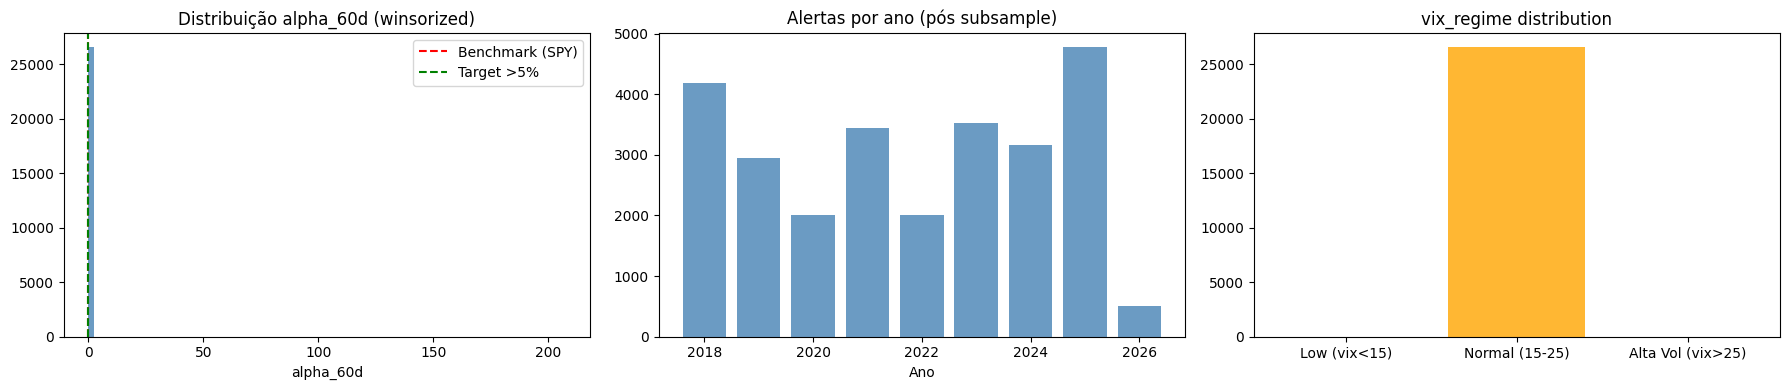

✅ Plot guardado: alpha_distribution_v32.png


In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Distribuição de alpha_60d
axes[0].hist(df_v31['alpha_60d'], bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].axvline(0, color='red', linewidth=1.5, linestyle='--', label='Benchmark (SPY)')
axes[0].axvline(0.05, color='green', linewidth=1.5, linestyle='--', label='Target >5%')
axes[0].set_title('Distribuição alpha_60d (winsorized)')
axes[0].set_xlabel('alpha_60d'); axes[0].legend()

# 2. Alertas por ano
yr_counts = df_v31.groupby(df_v31['alert_date'].dt.year).size()
axes[1].bar(yr_counts.index, yr_counts.values, color='steelblue', alpha=0.8)
axes[1].set_title('Alertas por ano (pós subsample)')
axes[1].set_xlabel('Ano')

# 3. vix_regime
if 'vix_regime' in df_v31.columns:                          # ← df_train → df_v31
    vc = df_v31['vix_regime'].value_counts().sort_index()   # ← df_train → df_v31
    axes[2].bar(['Low (vix<15)', 'Normal (15-25)', 'Alta Vol (vix>25)'],
                [vc.get(0.0, 0), vc.get(1.0, 0), vc.get(2.0, 0)],
                color=['steelblue', 'orange', 'tomato'], alpha=0.8)
    axes[2].set_title('vix_regime distribution')
else:
    axes[2].set_title('vix_regime: N/A')

plt.tight_layout()
plt.savefig('alpha_distribution_v32.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Plot guardado: alpha_distribution_v32.png')

## 🔄 Célula 4 — Walk-forward CV (10 folds)

In [ ]:
from ml_training.cv import walk_forward_cv
from ml_training.config import N_FOLDS, PURGE_DAYS, TOPK_FRAC, HALF_LIFE_DAYS
from ml_training.models import build_model_configs

MODEL_CONFIGS = build_model_configs(
    feature_cols_v31=FEATURE_COLS_V31,
    feature_cols_baseline=FEATURE_COLS_BASELINE,
)

print(f'Modelos candidatos: {list(MODEL_CONFIGS.keys())}')
print(f'Folds: {N_FOLDS}  |  Purge: {PURGE_DAYS}d  |  TopK: {TOPK_FRAC:.0%}')
print(f'vix_regime na lista de features: {"vix_regime" in FEATURE_COLS_V31}')

cv_results = walk_forward_cv(
    df=df_train,
    model_configs=MODEL_CONFIGS,
    feature_cols_map={name: cfg['feats'] for name, cfg in MODEL_CONFIGS.items()},
    target_col='alpha_60d',
    n_folds=N_FOLDS,
    purge_days=PURGE_DAYS,
    topk_frac=TOPK_FRAC,
    half_life_days=HALF_LIFE_DAYS,
)

print('\n✅ CV completo')

In [ ]:
import pandas as pd

cv_df = pd.DataFrame(cv_results)
print('CV Results por modelo:')
print(cv_df.groupby('model')[['ic', 'topk_alpha', 'hit_rate']].mean().round(4).to_string())

# Seleccionar champion: melhor IC médio
mean_ic = cv_df.groupby('model')['ic'].mean()
CHAMPION_NAME = mean_ic.idxmax()
CHAMPION_CFG  = MODEL_CONFIGS[CHAMPION_NAME]
print(f'\n🏆 Champion: {CHAMPION_NAME}  (mean IC={mean_ic[CHAMPION_NAME]:.4f})')

In [ ]:
import matplotlib.pyplot as plt

pivot = cv_df.pivot_table(index='fold', columns='model', values='ic')
pivot.plot(figsize=(12, 5), marker='o', title='IC por fold — Walk-forward CV v3.2')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.ylabel('Information Coefficient (IC)')
plt.tight_layout()
plt.savefig('cv_ic_v32.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Plot guardado: cv_ic_v32.png')

## 🎓 Célula 5 — Treino full + calibrador isotónico

In [ ]:
from ml_training.train import train_full_model

champion_model, isotonic_cal, scaler = train_full_model(
    df=df_train,
    champion_name=CHAMPION_NAME,
    champion_cfg=CHAMPION_CFG,
    target_col='alpha_60d',
    half_life_days=HALF_LIFE_DAYS,
)

print(f'✅ Modelo full treinado: {CHAMPION_NAME}')
print(f'   Features usadas: {len(CHAMPION_CFG["feats"])}')

## 📦 Célula 6 — Bundle + Report

In [ ]:
from ml_training.bundle import build_bundle, build_report, save_bundle, save_report

bundle = build_bundle(
    model=champion_model,
    isotonic_cal=isotonic_cal,
    scaler=scaler,
    feature_cols=CHAMPION_CFG['feats'],
    champion_name=CHAMPION_NAME,
    cv_results=cv_results,
    version='v3.2',
)

report = build_report(
    champion_name=CHAMPION_NAME,
    cv_results=cv_results,
    feature_cols=CHAMPION_CFG['feats'],
    version='v3.2',
    subsample_years=SUBSAMPLE_YEARS,
)

BUNDLE_PATH = REPO_PATH / 'dip_models_v3.pkl'
REPORT_PATH = REPO_PATH / 'ml_report_v3.json'

save_bundle(bundle, BUNDLE_PATH)
save_report(report, REPORT_PATH)

print(f'✅ Bundle: {BUNDLE_PATH}')
print(f'✅ Report: {REPORT_PATH}')
print(f'   Champion: {CHAMPION_NAME}')
print(f'   Features: {len(CHAMPION_CFG["feats"])}')
print(f'   Versão: v3.2')

## 💾 Célula 7 — Guardar parquet actualizado

In [ ]:
BASE_PARQUET = REPO_PATH / 'ml_training' / 'ml_training_base.parquet'

df_train.to_parquet(BASE_PARQUET, index=False)
print(f'✅ Parquet guardado: {BASE_PARQUET}')
print(f'   Linhas: {len(df_train):,}  |  Colunas: {df_train.shape[1]}')
print(f'   Período: {df_train["alert_date"].min().date()} → {df_train["alert_date"].max().date()}')
print(f'   vix_regime incluído: {"vix_regime" in df_train.columns}')

## ⬇️ Célula 8a — Download local dos artefactos (opcional)

In [ ]:
from google.colab import files

for path in [BUNDLE_PATH, REPORT_PATH, BASE_PARQUET]:
    if path.exists():
        files.download(str(path))
        print(f'⬇️  {path.name}')
    else:
        print(f'⚠️  Não encontrado: {path}')

## 🚀 Célula 8b — Push automático para GitHub

In [ ]:
import subprocess

subprocess.run(['git', '-C', REPO_DIR, 'config', 'user.email', 'colab@dipadar.ai'], check=True)
subprocess.run(['git', '-C', REPO_DIR, 'config', 'user.name', 'DipRadar Colab'], check=True)

files_to_add = [
    'dip_models_v3.pkl',
    'ml_report_v3.json',
    'ml_training/ml_training_base.parquet',
]

for f in files_to_add:
    subprocess.run(['git', '-C', REPO_DIR, 'add', f], check=True)

result = subprocess.run(
    ['git', '-C', REPO_DIR, 'diff', '--cached', '--name-only'],
    capture_output=True, text=True
)
staged = result.stdout.strip()

if staged:
    subprocess.run(
        ['git', '-C', REPO_DIR, 'commit', '-m',
         f'chore: retrain v3.2 — {CHAMPION_NAME} champion'],
        check=True
    )
    subprocess.run(['git', '-C', REPO_DIR, 'push', 'origin', BRANCH], check=True)
    print(f'✅ Push concluído — Railway vai fazer redeploy automático')
    print(f'   Ficheiros: {staged}')
else:
    print('ℹ️  Nada para commitar (artefactos sem alterações)')